In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import requests
from pathlib import Path

from tensorflow.keras.optimizers import Adam

I0000 00:00:1774333307.808039  129251 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
query = "NEPSECompanyExtractor"
companyDetails = pd.read_csv(f"../DATA-HTML-STOCK/NEPSECompany/{query}.csv")
symbols = companyDetails["Symbol"]
stock_ignored = ["CORBLP", "GFCLPO", "HBLPO", "LFCPO", "SBIPO", "GABLPO", "AMFIPO", "NMLBS", "ILFCPO"]
stock_no_news = ["HATHPO", "BUDBLP", "CFCLPO", "CORBLP", "EBLPO", "HAMROP", "HGIPO", "JFLPO", "JBNLPO", "KADBLP", "KNBLPO", "CEFLPO", "LBLPO", "MFILPO", "MIDBLP", "NBBLPO", "NABBPO", "NABBPO", "NBBPO", "PFLPO", "PRINPO", "PURBLP", "SBBLJP", "SIFCPO", "SILPO", "SMFDBP", "SYFLPO", "TNBLPO", "TDBLPO", "UFLPO", "WDBLPO", "WMBFPO", "HLBSLP"]


for symbol in symbols:
    print(f"Scoring {symbol} stock...")

    if symbol in stock_ignored:
        print(f"\n{symbol} is in ignore list!\n")
        continue

    if symbol in stock_no_news:
        print(f"\n{symbol} is in stock no news list!\n")
        continue

    filepath = f"../DATA-HTML-STOCK/NEPSEDATA/{symbol}.csv"
    data = pd.read_csv(filepath)
    
    data = data[['Close']]
    data.dropna(inplace=True)
    
    data['Close'] = data['Close'].astype(str).str.replace(',', '').astype(float)
    
    current_price = data.head().iloc[0,0]
    print(current_price)
    
    filename = Path(filepath).name.split('.')[0] 
    print(filename)
    print(data.head())


Scoring ADBL stock...
305.0
ADBL
   Close
0  305.0
1  302.6
2  298.0
3  294.6
4  293.0
Scoring API stock...
305.0
API
   Close
0  305.0
1  302.6
2  298.0
3  294.6
4  293.0
Scoring HATH stock...
305.0
HATH
   Close
0  305.0
1  302.6
2  298.0
3  294.6
4  293.0
Scoring HATHPO stock...

HATHPO is in stock no news list!

Scoring AKPL stock...
305.0
AKPL
   Close
0  305.0
1  302.6
2  298.0
3  294.6
4  293.0
Scoring AHPC stock...
305.0
AHPC
   Close
0  305.0
1  302.6
2  298.0
3  294.6
4  293.0
Scoring ALICL stock...
305.0
ALICL
   Close
0  305.0
1  302.6
2  298.0
3  294.6
4  293.0
Scoring ALICLP stock...
305.0
ALICLP
   Close
0  305.0
1  302.6
2  298.0
3  294.6
4  293.0
Scoring BOKL stock...
305.0
BOKL
   Close
0  305.0
1  302.6
2  298.0
3  294.6
4  293.0
Scoring BOKLPO stock...
305.0
BOKLPO
   Close
0  305.0
1  302.6
2  298.0
3  294.6
4  293.0
Scoring BARUN stock...
305.0
BARUN
   Close
0  305.0
1  302.6
2  298.0
3  294.6
4  293.0
Scoring BFC stock...
305.0
BFC
   Close
0  305.0
1  302.6
2  

/tmp/ipykernel_129251/3169065587.py:20: DtypeWarning: Columns (0: Open, 1: High, 2: Low, 3: Close) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(filepath)


305.0
KNBL
   Close
0  305.0
1  302.6
2  298.0
3  294.6
4  293.0
Scoring KNBLPO stock...

KNBLPO is in stock no news list!

Scoring KRBL stock...


/tmp/ipykernel_129251/3169065587.py:20: DtypeWarning: Columns (0: Open, 1: High, 2: Low, 3: Close) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(filepath)


305.0
KRBL
   Close
0  305.0
1  302.6
2  298.0
3  294.6
4  293.0
Scoring KRBLPO stock...


...

305.0
SRS
   Close
0  305.0
1  302.6
2  298.0
3  294.6
4  293.0
Scoring SFFIL stock...


/tmp/ipykernel_129251/3169065587.py:20: DtypeWarning: Columns (0: Open, 1: High, 2: Low, 3: Close) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(filepath)


305.0
SFFIL
   Close
0  305.0
1  302.6
2  298.0
3  294.6
4  293.0
Scoring SFFILP stock...


/tmp/ipykernel_129251/3169065587.py:20: DtypeWarning: Columns (0: Open, 1: High, 2: Low, 3: Close) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(filepath)


305.0
SFFILP
   Close
0  305.0
1  302.6
2  298.0
3  294.6
4  293.0
Scoring SCB stock...
305.0
SCB
   Close
0  305.0
1  302.6
2  298.0
3  294.6
4  293.0
Scoring SMFDB stock...
305.0
SMFDB
   Close
0  305.0
1  302.6
2  298.0
3  294.6
4  293.0
Scoring SMFDBP stock...

SMFDBP is in stock no news list!

Scoring SRBL stock...
305.0
SRBL
   Close
0  305.0
1  302.6
2  298.0
3  294.6
4  293.0
Scoring SRBLPO stock...
305.0
SRBLPO
   Close
0  305.0
1  302.6
2  298.0
3  294.6
4  293.0
Scoring SLICL stock...
305.0
SLICL
   Close
0  305.0
1  302.6
2  298.0
3  294.6
4  293.0
Scoring SLICLP stock...
305.0
SLICLP
   Close
0  305.0
1  302.6
2  298.0
3  294.6
4  293.0
Scoring SLBS stock...
305.0
SLBS
   Close
0  305.0
1  302.6
2  298.0
3  294.6
4  293.0
Scoring SWBBL stock...
305.0
SWBBL
   Close
0  305.0
1  302.6
2  298.0
3  294.6
4  293.0
Scoring SWBBLP stock...
305.0
SWBBLP
   Close
0  305.0
1  302.6
2  298.0
3  294.6
4  293.0
Scoring SDESI stock...
305.0
SDESI
   Close
0  305.0
1  302.6
2  298.0
3  2

In [3]:
data = data.iloc[::-1].reset_index(drop=True)

# 70% train, 15% validation, 15% test
train_size = int(0.7 * len(data))
val_size   = int(0.15 * len(data))

train_data = data.iloc[:train_size].values
val_data   = data.iloc[train_size:train_size+val_size].values
test_data  = data.iloc[train_size+val_size:].values

# Scale (fit ONLY on train)
scaler = MinMaxScaler(feature_range=(0, 1))

scaled_train = scaler.fit_transform(train_data)
scaled_val   = scaler.transform(val_data)
scaled_test  = scaler.transform(test_data)

In [4]:
def create_sequences(dataset, time_steps=60):
    X, y = [], []
    for i in range(time_steps, len(dataset)):
        X.append(dataset[i-time_steps:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

TIME_STEPS = 60

X_train, y_train = create_sequences(scaled_train, TIME_STEPS)
X_val, y_val     = create_sequences(scaled_val, TIME_STEPS)
X_test, y_test   = create_sequences(scaled_test, TIME_STEPS)

# reshape
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val   = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [6]:
dropout=0.2
neuron=64
learningrateofAdam=0.001
batchsize=32
epochIs=100
Patience=15

model = Sequential([
    LSTM(neuron, return_sequences=True, input_shape=(TIME_STEPS, 1)),
    Dropout(dropout),
    LSTM(neuron),
    Dropout(dropout),
    Dense(1)
])

optimizer = Adam(learning_rate=learningrateofAdam)

model.compile(
    optimizer=optimizer,
    loss='mean_squared_error'
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=Patience,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=epochIs,
    batch_size=batchsize,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - loss: 0.0049 - val_loss: 3.3310e-04
Epoch 2/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 0.0014 - val_loss: 3.6546e-04
Epoch 3/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 0.0013 - val_loss: 2.9938e-04
Epoch 4/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 0.0013 - val_loss: 2.5402e-04
Epoch 5/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - loss: 0.0012 - val_loss: 2.7728e-04
Epoch 6/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - loss: 0.0010 - val_loss: 2.2737e-04
Epoch 7/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - loss: 9.7623e-04 - val_loss: 2.2150e-04
Epoch 8/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 8.5844e-04 - val_loss: 3.0355e-04
Epoch 9/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - loss: 7.9437e-04 - val_loss: 1.8467e-04
Epoch 10/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - loss: 7.9972e-04 - val_loss: 1.7217e-04
Epoch 11/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - loss

In [8]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (4863, 60, 1)
X_test shape: (996, 60, 1)


In [1]:
model.save(f"{stock}_lstm_pretrained_model.h5")

In [10]:
from tensorflow.keras.models import load_model
model = load_model(f"{stock}_lstm_pretrained_model.h5")


In [11]:
predictions = model.predict(X_test)
predictions_actual = scaler.inverse_transform(predictions).flatten()
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


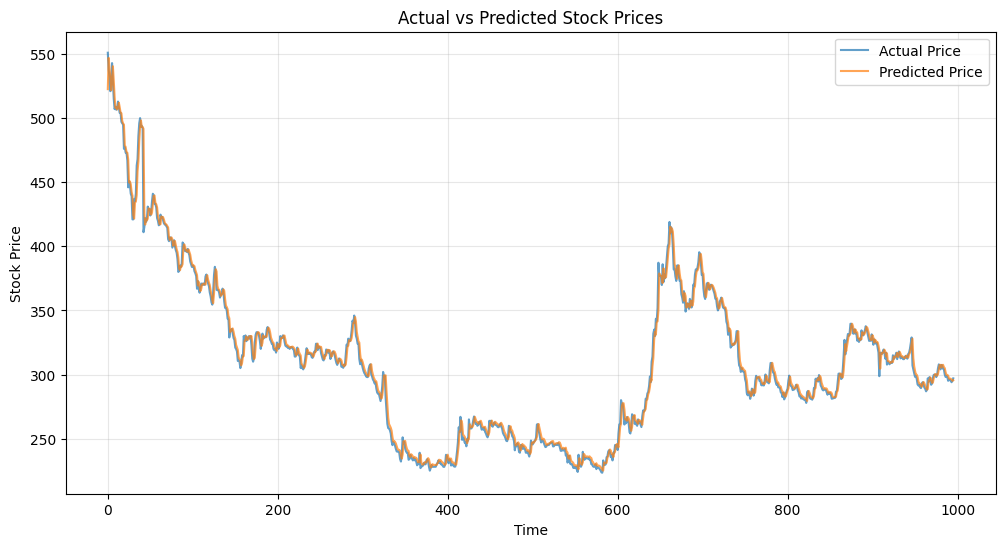

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label='Actual Price', alpha=0.7)
plt.plot(predictions_actual, label='Predicted Price', alpha=0.7)
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.title("Actual vs Predicted Stock Prices")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions_actual))
print(f"\nRMSE: {rmse:.2f}")

from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test_actual, predictions_actual)
print(f"MAE: {mae:.2f}")

mape = np.mean(np.abs((y_test_actual - predictions_actual) / y_test_actual)) * 100
print(f"MAPE: {mape:.2f}%")


RMSE: 5.95
MAE: 3.87
MAPE: 1.23%


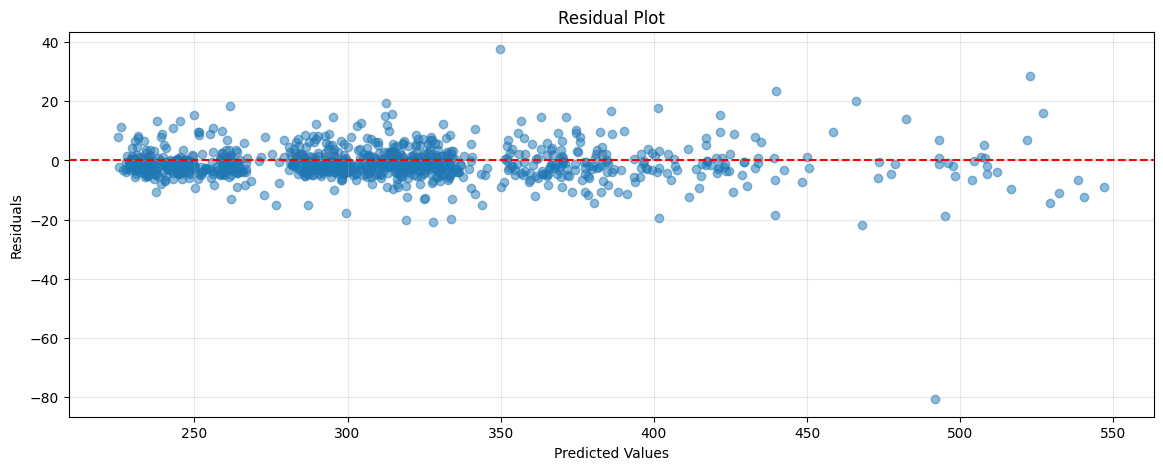

In [14]:
residuals = y_test_actual - predictions_actual
plt.figure(figsize=(14, 5))

plt.subplot(1, 1, 1)
plt.scatter(predictions_actual, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True, alpha=0.3)

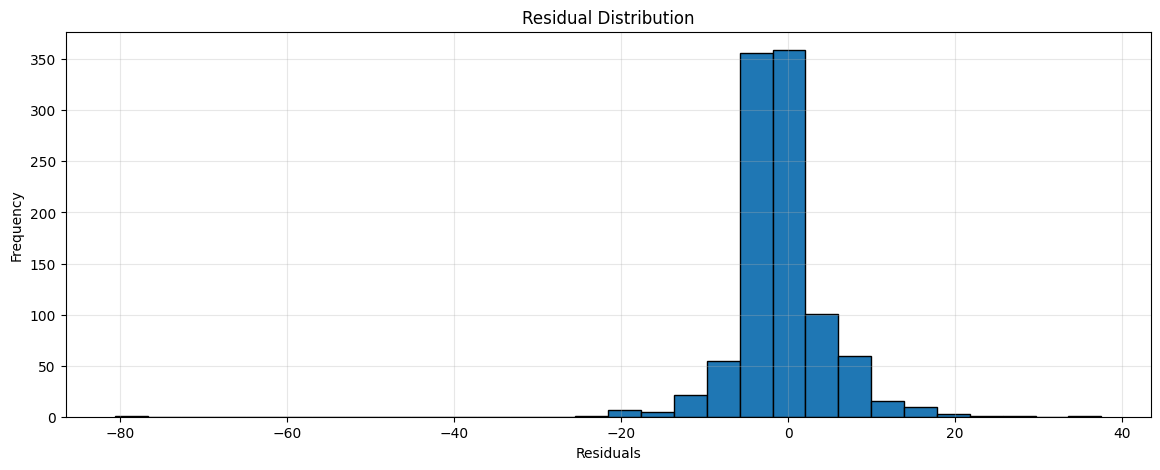

In [15]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 1, 1)
plt.hist(residuals, bins=30, edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Residual Distribution')
plt.grid(True, alpha=0.3)
plt.show()

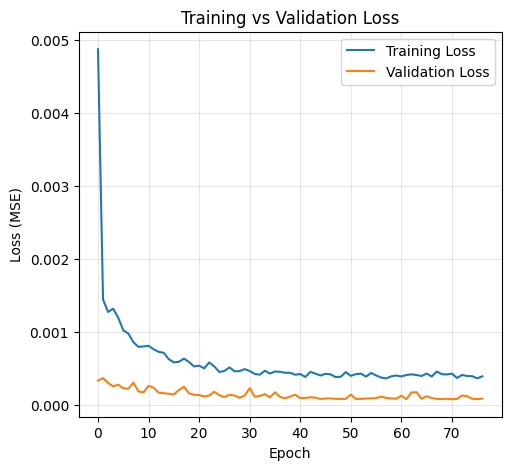

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

In [17]:
last_60_days = scaled_test[-60:]

last_60_days = last_60_days.reshape(1, 60, 1)

predicted_scaled = model.predict(last_60_days, verbose=0)
predicted_price = scaler.inverse_transform(predicted_scaled)

print(f"tomorrow predicted price: {predicted_price[0][0]:.2f}")

tomorrow predicted price: 297.12


In [1]:
import tensorflow as tf
print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

2026-03-23 09:15:48.665038: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-23 09:15:48.880719: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-23 09:15:48.936431: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-23 09:15:49.389960: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-23 09:16:02.104228: W tensorflow/compiler/tf2

TF version: 2.17.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


I0000 00:00:1774257389.003656   12422 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1774257389.621663   12422 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1774257389.621789   12422 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [2]:
import tensorflow as tf
tf.debugging.set_log_device_placement(True)

# Check if TF can see CUDA at all
print(tf.test.is_built_with_cuda())
print(tf.test.is_gpu_available())  # deprecated but still informative

True
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
True


I0000 00:00:1774257389.634786   12422 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1774257389.635208   12422 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1774257389.635398   12422 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1774257390.564334   12422 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1774257390.564425   12422 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-23

In [8]:
import requests

symbol = "ADBL"
current_price = 294.3
tomorrow_price = 296.12
StockTodaydate = "2020-12-01"

try:
    responses = requests.post('http://192.168.254.6:3000/predicted_price', json={"predicted_price":float(tomorrow_price), "stock":symbol, "date":StockTodaydate, "current_price":current_price})
    print(f'{responses}')
    print(f'{responses.json()}')
except Exception as e:
    print("Error sending data: ", e)

<Response [500]>
{'status': False, 'message': 'Table created failed'}


In [1]:
# 💡 Summary in 1 sentence each:

# RMSE: Focus on large errors, lower = better.

# MAE: Average error, lower = better.

# MAPE: Percentage error, lower = better.

# R²: How well model explains variation, closer to 1 = better.

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [3]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from IPython.display import clear_output
import requests

I0000 00:00:1774373242.929610   18429 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
# ================= CONFIG =================
BASE_DIR   = "../STOCK-EVALUATION-DATA-FIGURE/"
MODELS_DIR = "../DATA-HTML-STOCK/Models"

TIME_STEPS  = 60
dropout     = 0.2
neuron      = 64
lr          = 0.001
batchsize   = 32
epochIs     = 100
patience    = 15

os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)


# ================= DATA =================
query = "NEPSECompanyExtractor"
companyDetails = pd.read_csv(f"../DATA-HTML-STOCK/NEPSECompany/{query}.csv")
symbols = companyDetails["Symbol"]

stock_ignored = ["CORBLP", "GFCLPO", "HBLPO", "LFCPO", "SBIPO", "GABLPO", "AMFIPO", "NMLBS", "ILFCPO", "JSLBBP"]

stock_no_news = ["HATHPO", "BUDBLP", "CFCLPO", "CORBLP", "EBLPO", "HAMROP", "HGIPO", "JFLPO", "JBNLPO",
                 "KADBLP", "KNBLPO", "CEFLPO", "LBLPO", "MFILPO", "MIDBLP", "NBBLPO", "NABBPO", "NBBPO",
                 "PFLPO", "PRINPO", "PURBLP", "SBBLJP", "SIFCPO", "SILPO", "SMFDBP", "SYFLPO", "TNBLPO",
                 "TDBLPO", "UFLPO", "WDBLPO", "WMBFPO", "HLBSLP"]

needCompareModel = ["ADBL", "BARUN", "API", "NABIL", "NICA", "NTC"]


In [5]:

# ================= FUNCTIONS =================
def create_sequences(dataset, time_steps=60):
    X, y = [], []
    for i in range(time_steps, len(dataset)):
        X.append(dataset[i-time_steps:i])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)


def build_model(time_steps, n_features):
    model = Sequential([
        LSTM(neuron, return_sequences=True,
             input_shape=(time_steps, n_features),
             activation='tanh',
             recurrent_activation='sigmoid'),

        Dropout(dropout),

        LSTM(neuron,
             activation='tanh',
             recurrent_activation='sigmoid'),

        Dropout(dropout),

        Dense(1)
    ])

    model.compile(optimizer=Adam(learning_rate=lr), loss='mean_squared_error')
    model.summary()
    return model


# ================= SUMMARY =================
summary_path = os.path.join(BASE_DIR, "summary.csv")




===== Processing ADBL =====


E0000 00:00:1774373270.401018   18429 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
MSE: 36.08 |RMSE: 6.01 | MAE: 4.10 | MAPE: 1.32%| R²: 0.9803


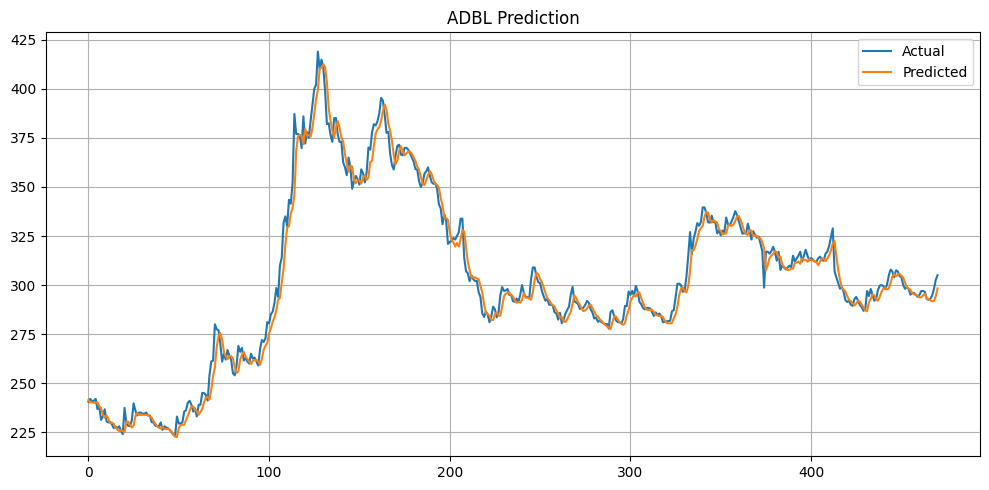

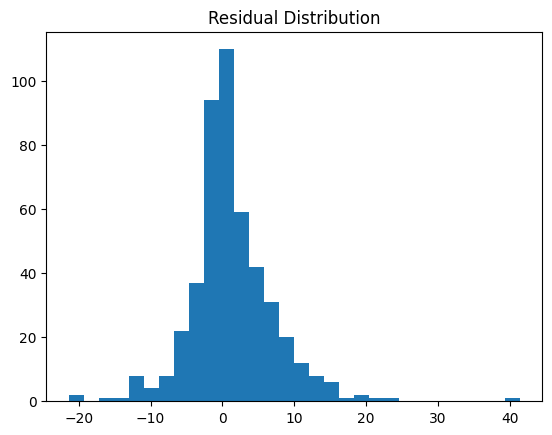

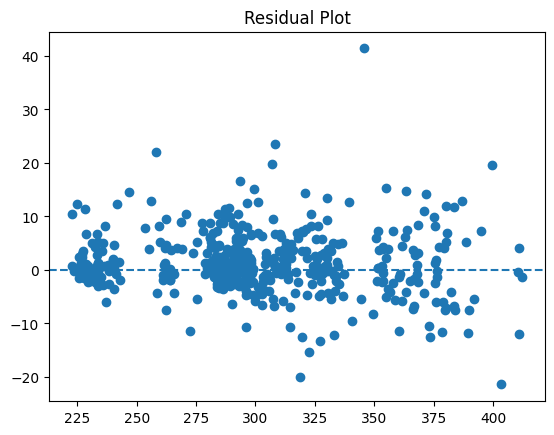

Tomorrow price: 302.01
<Response [200]>
send sucess
{'status': True, 'message': 'Predicted price table created and data uploaded successfully'}
done ADBL

===== Processing API =====
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
MSE: 17.92 |RMSE: 4.23 | MAE: 3.32 | MAPE: 1.18%| R²: 0.9904


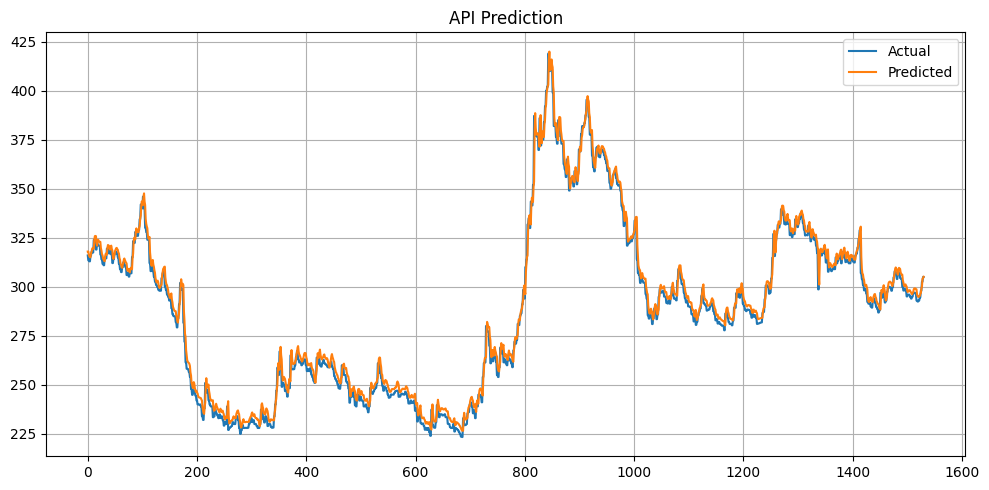

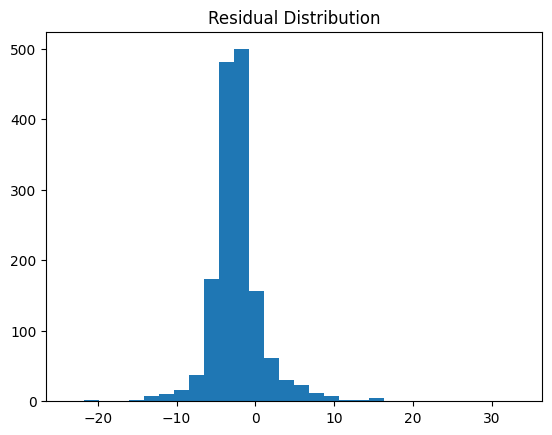

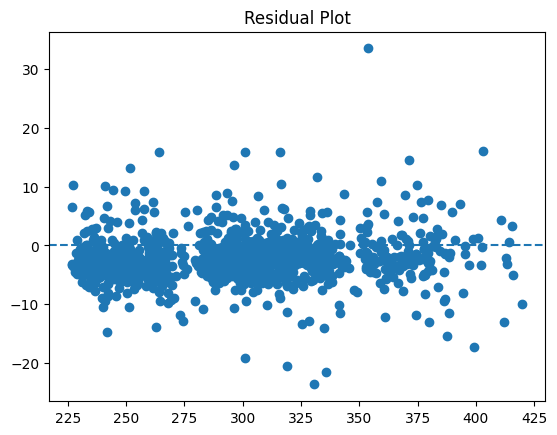

Tomorrow price: 305.15
<Response [200]>
send sucess
{'status': True, 'message': 'Predicted price table created and data uploaded successfully'}
done API

===== Processing HATH =====
HATH not the stock we are trying to do analysis

===== Processing HATHPO =====
HATHPO not the stock we are trying to do analysis

===== Processing AKPL =====
AKPL not the stock we are trying to do analysis

===== Processing AHPC =====
AHPC not the stock we are trying to do analysis

===== Processing ALICL =====
ALICL not the stock we are trying to do analysis

===== Processing ALICLP =====
ALICLP not the stock we are trying to do analysis

===== Processing BOKL =====
BOKL not the stock we are trying to do analysis

===== Processing BOKLPO =====
BOKLPO not the stock we are trying to do analysis

===== Processing BARUN =====


548/548 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step
MSE: 25.71 |RMSE: 5.07 | MAE: 1.95 | MAPE: 0.48%| R²: 0.9983


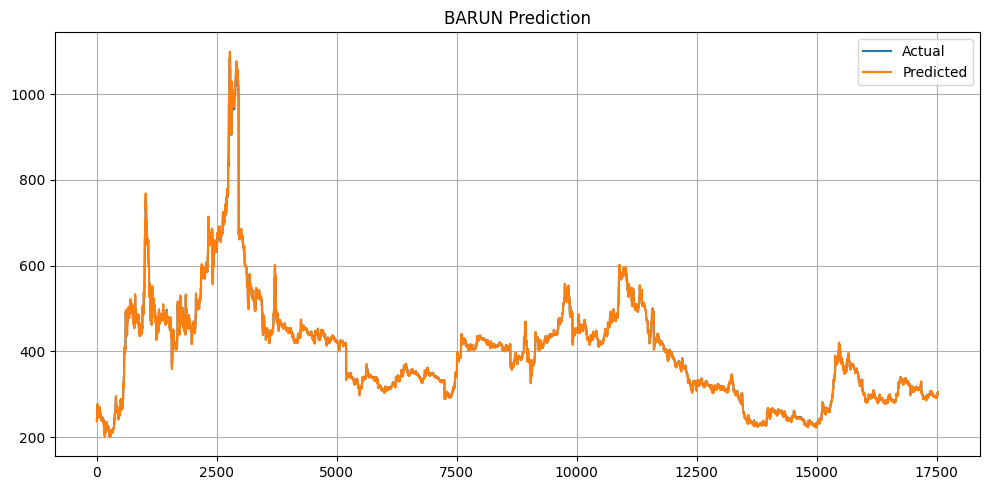

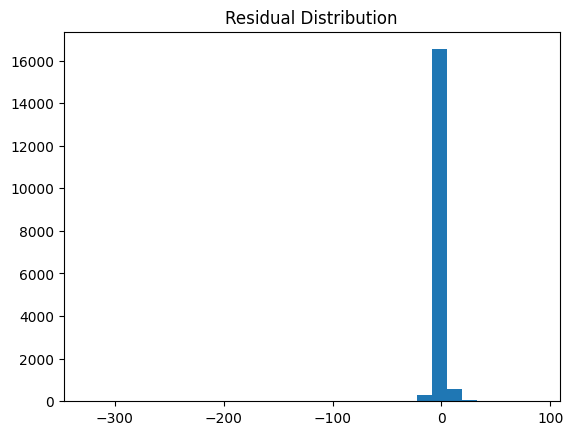

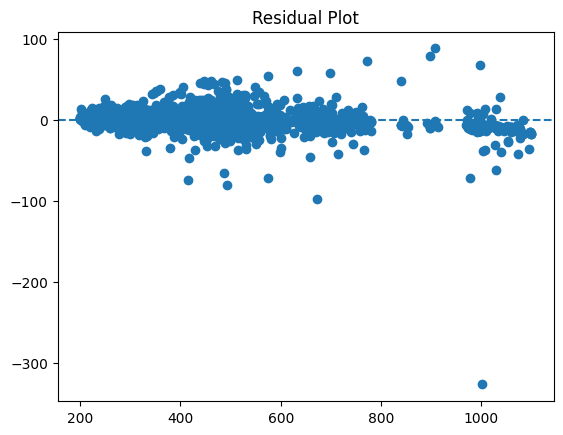

Tomorrow price: 304.59
<Response [200]>
send sucess
{'status': True, 'message': 'Predicted price table created and data uploaded successfully'}
done BARUN

===== Processing BFC =====
BFC not the stock we are trying to do analysis

===== Processing BFCPO =====
BFCPO not the stock we are trying to do analysis

===== Processing BHBL =====
BHBL not the stock we are trying to do analysis

===== Processing BHBLPO =====
BHBLPO not the stock we are trying to do analysis

===== Processing BBC =====
BBC not the stock we are trying to do analysis

===== Processing BNT =====
BNT not the stock we are trying to do analysis

===== Processing BNL =====
BNL not the stock we are trying to do analysis

===== Processing BUDBL =====
BUDBL not the stock we are trying to do analysis

===== Processing BUDBLP =====
BUDBLP not the stock we are trying to do analysis

===== Processing BPCL =====
BPCL not the stock we are trying to do analysis

===== Processing CFCL =====
CFCL not the stock we are trying to do ana

MemoryError: Unable to allocate 6.80 GiB for an array with shape (7610926, 60, 2) and data type float64

In [6]:

# ================= MAIN LOOP =================
for symbol in symbols:
    print(f"\n===== Processing {symbol} =====")

    if symbol not in needCompareModel:
        print(f"{symbol} not the stock we are trying to do analysis")
        continue

    if symbol in stock_ignored:
        print(f"{symbol} ignored")
        continue

    # --- folder per stock ---
    symbol_path = os.path.join(BASE_DIR, symbol)
    os.makedirs(symbol_path, exist_ok=True)

    stock_path = f"../DATA-HTML-STOCK/NEPSEDATA/{symbol}.csv"
    final_path = f"../DATA-HTML-STOCK/FinalDataSet/{symbol}.csv"
    model_path = os.path.join(MODELS_DIR, f"{symbol}_lstm.h5")

    if not os.path.exists(stock_path) or not os.path.exists(final_path):
        print(f"{symbol} missing data, skipping")
        continue

    # --- load stock ---
    stock_df = pd.read_csv(stock_path)
    stock_df = stock_df[['Date', 'Close']].dropna()
    stock_df['Close'] = stock_df['Close'].astype(str).str.replace(',', '').astype(float)
    stock_df['Date'] = pd.to_datetime(stock_df['Date'])

    # --- load sentiment ---
    sentiment_df = pd.read_csv(final_path)
    sentiment_df = sentiment_df[['Date_Stock', 'Decayed_Sentiment']]
    sentiment_df['Date_Stock'] = pd.to_datetime(sentiment_df['Date_Stock'])

    # --- merge ---
    data = pd.merge(stock_df, sentiment_df, left_on='Date', right_on='Date_Stock', how='left')
    data = data[['Date', 'Close', 'Decayed_Sentiment']]

    if symbol in stock_no_news:
        data['Decayed_Sentiment'] = 0.0
    else:
        data['Decayed_Sentiment'] = data['Decayed_Sentiment'].fillna(0.0)

    data = data.dropna(subset=['Close'])
    data = data.iloc[::-1].reset_index(drop=True)

    if len(data) < TIME_STEPS + 10:
        print(f"{symbol} not enough data")
        continue

    current_price = data['Close'].iloc[-1]
    values = data[['Close', 'Decayed_Sentiment']].values

    # --- split ---
    train_size = int(0.7 * len(values))
    val_size   = int(0.15 * len(values))

    train_data = values[:train_size]
    val_data   = values[train_size:train_size+val_size]
    test_data  = values[train_size+val_size:]

    # --- scaling ---
    scaler = MinMaxScaler()
    scaled_train = scaler.fit_transform(train_data)
    scaled_val   = scaler.transform(val_data)
    scaled_test  = scaler.transform(test_data)

    close_scaler = MinMaxScaler()
    close_scaler.fit(train_data[:, 0].reshape(-1, 1))

    X_train, y_train = create_sequences(scaled_train, TIME_STEPS)
    X_val,   y_val   = create_sequences(scaled_val, TIME_STEPS)
    X_test,  y_test  = create_sequences(scaled_test, TIME_STEPS)

    if len(X_train) == 0 or len(X_test) == 0:
        print(f"{symbol} insufficient sequences")
        continue

    # --- model ---
    if os.path.exists(model_path):
        model = load_model(model_path)
    else:
        model = build_model(TIME_STEPS, 2)

        early_stop = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)

        history = model.fit(
            X_train, y_train,
            epochs=epochIs,
            batch_size=batchsize,
            validation_data=(X_val, y_val),
            callbacks=[early_stop],
            verbose=1
        )

        model.save(model_path)

        # --- training plot ---
        plt.figure(figsize=(10, 5))
        plt.plot(history.history['loss'], label='Train Loss')
        plt.plot(history.history['val_loss'], label='Val Loss')
        plt.legend()
        plt.title(f"{symbol} Loss")
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(symbol_path, "training_loss.png"), dpi=300)
        plt.show()
        plt.close()

    # --- prediction ---
    predictions = model.predict(X_test)
    predictions_actual = close_scaler.inverse_transform(predictions).flatten()
    y_test_actual = close_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    # --- residuals ---
    residuals = y_test_actual - predictions_actual

    # --- metrics ---
    mse = mean_squared_error(y_test_actual, predictions_actual)
    rmse = np.sqrt(mean_squared_error(y_test_actual, predictions_actual))
    mae  = mean_absolute_error(y_test_actual, predictions_actual)
    mape = np.mean(np.abs(residuals / y_test_actual)) * 100
    r2   = r2_score(y_test_actual, predictions_actual)

    print(f"MSE: {mse:.2f} |RMSE: {rmse:.2f} | MAE: {mae:.2f} | MAPE: {mape:.2f}%| R²: {r2:.4f}")

    # --- plots ---
    plt.figure(figsize=(10, 5))
    plt.plot(y_test_actual, label='Actual')
    plt.plot(predictions_actual, label='Predicted')
    plt.legend()
    plt.title(f"{symbol} Prediction")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(symbol_path, "prediction.png"), dpi=300)
    plt.show()
    plt.close()

    plt.figure()
    plt.hist(residuals, bins=30)
    plt.title("Residual Distribution")
    plt.savefig(os.path.join(symbol_path, "residual_hist.png"))
    plt.show()
    plt.close()

    plt.figure()
    plt.scatter(predictions_actual, residuals)
    plt.axhline(0, linestyle='--')
    plt.title("Residual Plot")
    plt.savefig(os.path.join(symbol_path, "residual_plot.png"))
    plt.show()
    plt.close()

    # --- tomorrow prediction ---
    last_60 = scaled_test[-TIME_STEPS:].reshape(1, TIME_STEPS, 2)
    tomorrow_scaled = model.predict(last_60, verbose=0)
    tomorrow_price = close_scaler.inverse_transform(tomorrow_scaled)[0][0]

    print(f"Tomorrow price: {tomorrow_price:.2f}")

    # --- save metrics ---
    metrics = {
        "symbol": symbol,
        "current_price": float(current_price),
        "tomorrow_price": float(tomorrow_price),
        "mse": float(mse),
        "rmse": float(rmse),
        "mae": float(mae),
        "mape": float(mape),
        "r2": float(r2) 
    }

    with open(os.path.join(symbol_path, "metrics.json"), "w") as f:
        json.dump(metrics, f, indent=4)

    # --- save predictions ---
    df_pred = pd.DataFrame({
        "Actual": y_test_actual,
        "Predicted": predictions_actual,
        "Residual": residuals
    })
    df_pred.to_csv(os.path.join(symbol_path, "predictions.csv"), index=False)

    # --- update global summary (no duplicates) ---
    summary_df = pd.DataFrame([metrics])

    if os.path.exists(summary_path):
        existing = pd.read_csv(summary_path)
        existing = existing[existing["symbol"] != symbol]
        existing = pd.concat([existing, summary_df], ignore_index=True)
        existing.to_csv(summary_path, index=False)
    else:
        summary_df.to_csv(summary_path, index=False)


    #clear_output(wait=True)

    current_price = metrics["current_price"]
    tomorrow_price = metrics["tomorrow_price"]
    StockTodaydate = data['Date'].iloc[-1].strftime('%Y-%m-%d')

    
    try:
        responses = requests.post('http://192.168.254.6:3000/predicted_price', json={"predicted_price":float(tomorrow_price), "stock":symbol, "date":StockTodaydate, "current_price":current_price})
        print(f'{responses}')
        print(f'send sucess')
        print(f'{responses.json()}')
    except Exception as e:
        print("Error sending data: ", e)

    print(f"done {symbol}")


print("\nAll stocks processed successfully.")